In [1]:
import datetime
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from utils import find_contract_expiry

In [2]:
etf_returns = pl.read_excel("./etf returns.xlsx")
# display(etf_returns.head(2))

cboe_vx = pl.read_excel("./cboe vx.xlsx")
# display(cboe_vx.head(2))

In [3]:
left = etf_returns.select([pl.col("column_0").alias("date"), "BATS:VIXY - Return"])
right = etf_returns.select(["_1", "ARCX:SPY - Return"])
etf_returns = left.join(right, left_on="date", right_on="_1", how="inner")
etf_returns = etf_returns.sort(by="date")
etf_returns = etf_returns.rename({"date": "Trade Date"})

print(f"vx zero close prices: {cboe_vx.select(pl.col('Close') == 0).sum().item()}")
# cloes prices are actually handled differently in futures markets. if there are no trades in the last minutes of the trading day, the exchange will mark the close as 0.
# lets just use the settle price, which is apparently the preferred price metric used in futures markets
cboe_vx = cboe_vx.select([
    pl.col("Trade Date"), 
    pl.col("Futures").alias("Contract Date"), 
    pl.col("Futures")
        .str.extract(r"\((.*)\)", 1) # fuck regex
        .str.to_date(format="%b %Y")
        .map_elements(find_contract_expiry, return_dtype=pl.Date)
        .alias("Contract Expiry"), 
    pl.col("Settle")
])
cboe_vx = cboe_vx.with_columns((pl.col("Contract Expiry") - pl.col("Trade Date")).dt.total_days().alias("Days to Expiry"))

cboe_vx = cboe_vx.sort(by="Trade Date")

display(etf_returns.head(2))
display(cboe_vx.head(2))

vx zero close prices: 75


Trade Date,BATS:VIXY - Return,ARCX:SPY - Return
date,f64,f64
2023-03-17,10.5315,-1.16478
2023-03-20,-4.18522,0.96156


Trade Date,Contract Date,Contract Expiry,Settle,Days to Expiry
date,str,date,f64,i64
2024-04-22,"""F (Jan 2025)""",2025-01-22,19.25,275
2024-04-23,"""F (Jan 2025)""",2025-01-22,18.7,274


In [4]:
dates = cboe_vx.select(pl.col("Trade Date")).unique()

from utils import interp_targets
curve_table = cboe_vx.group_by("Trade Date").map_groups(interp_targets).sort("Trade Date").drop_nulls()
curve_table = curve_table.with_columns([(pl.col("t_7") / pl.col("t_30")).alias("7/30 ratio"), (pl.col("t_30") / pl.col("t_60")).alias("30/60 ratio"), (pl.col("t_30") / pl.col("t_90")).alias("30/90 ratio"), (pl.col("t_30") / pl.col("t_120")).alias("30/120 ratio")])
curve_table = curve_table.with_columns([(pl.col("t_7") > pl.col("t_30")).alias("7/30 flag"), (pl.col("t_30") > pl.col("t_60")).alias("30/60 flag"), (pl.col("t_30") > pl.col("t_90")).alias("30/90 flag"), (pl.col("t_30") > pl.col("t_120")).alias("30/120 flag")])
curve_table

Trade Date,t_7,t_30,t_60,t_90,t_120,7/30 ratio,30/60 ratio,30/90 ratio,30/120 ratio,7/30 flag,30/60 flag,30/90 flag,30/120 flag
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool
2025-01-15,16.101,16.891214,17.721661,18.1868,18.448926,0.953217,0.953139,0.928762,0.915566,false,false,false,false
2025-01-16,16.221525,16.9696,17.707821,18.1258,18.353543,0.955917,0.958311,0.936212,0.924595,false,false,false,false
2025-01-17,16.254843,17.124736,17.813782,18.202037,18.377151,0.949203,0.961319,0.940814,0.931849,false,false,false,false
2025-01-21,15.519671,16.567236,17.444779,17.931757,18.1997,0.936769,0.949696,0.923905,0.910303,false,false,false,false
2025-01-22,15.8333,16.803536,17.646371,18.040537,18.255357,0.94226,0.952237,0.931432,0.920471,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-17,20.091471,20.234764,20.722389,20.937274,21.1533,0.992918,0.976469,0.966447,0.956577,false,false,false,false
2026-02-18,19.807175,20.201979,20.794669,21.020183,21.289671,0.980457,0.971498,0.961075,0.94891,false,false,false,false
2026-03-11,23.5823,23.061104,22.9088,22.857557,23.046957,1.022601,1.006648,1.008905,1.000614,true,true,true,true


In [5]:
main = etf_returns.join(curve_table, on="Trade Date")
data = main

In [6]:
from utils import add_cumret
short = main
main = add_cumret(main, "7/30 flag", "BATS:VIXY - Return")
main = add_cumret(main, "30/60 flag", "BATS:VIXY - Return")
main = add_cumret(main, "30/90 flag", "BATS:VIXY - Return")
main = add_cumret(main, "30/120 flag", "BATS:VIXY - Return")
main

Trade Date,BATS:VIXY - Return,ARCX:SPY - Return,t_7,t_30,t_60,t_90,t_120,7/30 ratio,30/60 ratio,30/90 ratio,30/120 ratio,7/30 flag,30/60 flag,30/90 flag,30/120 flag,return earned: 7/30 flag (shifted),cumret: 7/30 flag,return earned: 30/60 flag (shifted),cumret: 30/60 flag,return earned: 30/90 flag (shifted),cumret: 30/90 flag,return earned: 30/120 flag (shifted),cumret: 30/120 flag
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-15,-8.36722,1.81899,16.101,16.891214,17.721661,18.1868,18.448926,0.953217,0.953139,0.928762,0.915566,false,false,false,false,-0.0,1.0,-0.0,1.0,-0.0,1.0,-0.0,1.0
2025-01-16,0.18683,-0.19231,16.221525,16.9696,17.707821,18.1258,18.353543,0.955917,0.958311,0.936212,0.924595,false,false,false,false,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2025-01-17,0.55944,1.00399,16.254843,17.124736,17.813782,18.202037,18.377151,0.949203,0.961319,0.940814,0.931849,false,false,false,false,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2025-01-21,-4.07974,0.91536,15.519671,16.567236,17.444779,17.931757,18.1997,0.936769,0.949696,0.923905,0.910303,false,false,false,false,-0.0,1.0,-0.0,1.0,-0.0,1.0,-0.0,1.0
2025-01-22,1.40164,0.56214,15.8333,16.803536,17.646371,18.040537,18.255357,0.94226,0.952237,0.931432,0.920471,false,false,false,false,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-17,-3.56764,0.16135,20.091471,20.234764,20.722389,20.937274,21.1533,0.992918,0.976469,0.966447,0.956577,false,false,false,false,-0.0,0.959172,-0.0,0.785062,-0.0,0.785062,-0.0,0.785062
2026-02-18,0.25641,0.50377,19.807175,20.201979,20.794669,21.020183,21.289671,0.980457,0.971498,0.961075,0.94891,false,false,false,false,0.25641,0.961632,0.25641,0.787075,0.25641,0.787075,0.25641,0.787075
2026-03-11,-4.55936,-0.12552,23.5823,23.061104,22.9088,22.857557,23.046957,1.022601,1.006648,1.008905,1.000614,true,true,true,true,-4.55936,0.917788,-4.55936,0.75119,-4.55936,0.75119,-4.55936,0.75119


In [7]:
short = short.with_columns((~pl.col("30/60 flag")).alias("inverse 30/60 flag"))
short = add_cumret(short, "inverse 30/60 flag", "BATS:VIXY - Return")

23


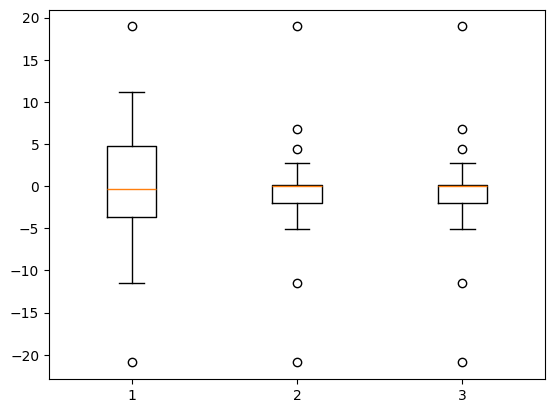

In [8]:
box_data = main.filter((pl.col("return earned: 7/30 flag (shifted)") != 0) | (pl.col("return earned: 30/60 flag (shifted)") != 0) | (pl.col("return earned: 30/90 flag (shifted)") != 0)).select([pl.col("Trade Date"), pl.col("return earned: 7/30 flag (shifted)"), pl.col("return earned: 30/60 flag (shifted)"), pl.col("return earned: 30/90 flag (shifted)")])
print(len(box_data))
fig, ax = plt.subplots()
ax.boxplot([box_data["return earned: 7/30 flag (shifted)"], box_data["return earned: 30/60 flag (shifted)"], box_data["return earned: 30/90 flag (shifted)"]])
plt.show()

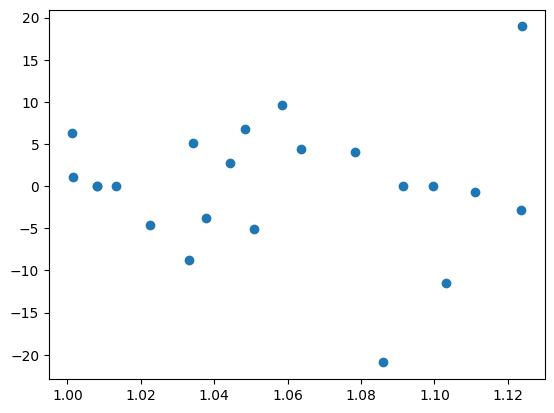

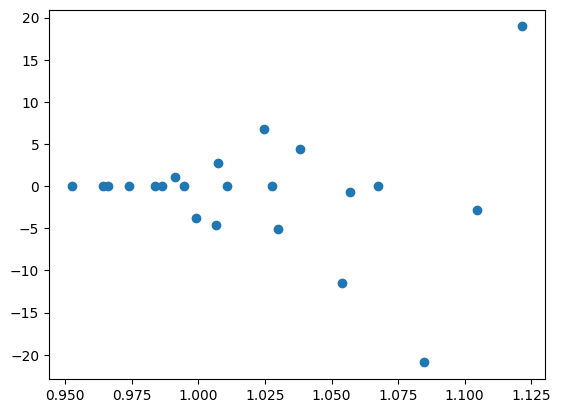

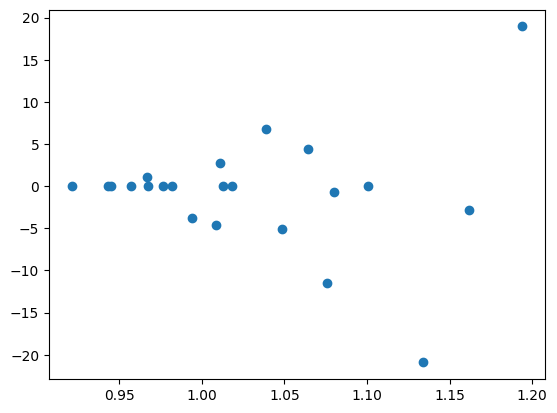

In [9]:
# check to see if the greater the ratio of front month : back month, the higher the return on VIXY 
linreg_data = main.filter((pl.col("7/30 flag") != 0) | (pl.col("30/60 flag") != 0) | (pl.col("30/90 flag")) != 0).select([pl.col("7/30 ratio"), pl.col("30/60 ratio"), pl.col("30/90 ratio"), pl.col("return earned: 7/30 flag (shifted)"), pl.col("return earned: 30/60 flag (shifted)"), pl.col("return earned: 30/90 flag (shifted)")])
fig, ax = plt.subplots()
ax.scatter(linreg_data["7/30 ratio"], linreg_data["return earned: 7/30 flag (shifted)"])
plt.show()

fig, ax = plt.subplots()
ax.scatter(linreg_data["30/60 ratio"], linreg_data["return earned: 30/60 flag (shifted)"])
plt.show()

fig, ax = plt.subplots()
ax.scatter(linreg_data["30/90 ratio"], linreg_data["return earned: 30/90 flag (shifted)"])
plt.show()

In [10]:
# hit rate
hit_rate = main.select(pl.col("return earned: 7/30 flag (shifted)") > 0).sum().item() / main.select(pl.col("return earned: 7/30 flag (shifted)") != 0).sum().item()
print(f"7/30 hit rate: {hit_rate}")
hit_rate = main.select(pl.col("return earned: 30/60 flag (shifted)") > 0).sum().item() / main.select(pl.col("return earned: 30/60 flag (shifted)") != 0).sum().item()
print(f"30/60 hit rate: {hit_rate}")
hit_rate = main.select(pl.col("return earned: 30/90 flag (shifted)") > 0).sum().item() / main.select(pl.col("return earned: 30/90 flag (shifted)") != 0).sum().item()
print(f"30/90 hit rate: {hit_rate}")


7/30 hit rate: 0.4782608695652174
30/60 hit rate: 0.42857142857142855
30/90 hit rate: 0.42857142857142855


In [11]:
from utils import build_ratio_table, bucket_on_ratio, bucket_on_ratio_inverted
ratio = build_ratio_table(data, "7", "30")
bucket = bucket_on_ratio(ratio, "7/30", fwd=True)
display(bucket)
inv_bucket = bucket_on_ratio_inverted(ratio, "7/30", fwd=True)
display(inv_bucket)

Ratio Bucket 7/30,n,Average Ratio,Mean Return,Median Return,Std Dev
cat,u32,f64,f64,f64,f64
"""(-inf, 0.9227056905248976]""",21,0.903662,0.461581,0.24433,2.888258
"""(0.9227056905248976, 0.9532174…",20,0.936723,0.497458,-0.05223,2.720011
"""(0.9532174376366412, 1.0016517…",20,0.976734,0.006896,-0.129295,4.909868
"""(1.0016517010034496, inf]""",20,1.062022,-1.270498,-1.63844,8.353895


Ratio Bucket 7/30,n,Average Ratio,Mean Return,Median Return,Std Dev,Hit Rate
cat,u32,f64,f64,f64,f64,f64
"""(-inf, 1.0252624826033954]""",6,1.009121,1.065872,0.54494,6.419548,0.5
"""(1.0252624826033954, 1.0496045…",5,1.039587,-3.224416,1.68067,10.334035,0.6
"""(1.049604504729517, 1.09015202…",5,1.067503,0.75345,-2.53061,11.472623,0.4
"""(1.0901520208287865, inf]""",6,1.108843,-1.387385,-1.797855,6.644705,0.333333


In [12]:
ratio = build_ratio_table(data, "30", "60")
bucket = bucket_on_ratio(ratio, "30/60")
display(bucket)
inv_bucket = bucket_on_ratio_inverted(ratio, "30/60")
display(inv_bucket)

Ratio Bucket 30/60,n,Average Ratio,Mean Return,Median Return,Std Dev
cat,u32,f64,f64,f64,f64
"""(-inf, 0.9266670187297563]""",21,0.921226,-0.036042,-0.10446,1.536364
"""(0.9266670187297563, 0.9597435…",20,0.949464,1.187747,0.328895,3.65638
"""(0.9597435464280397, 0.9837039…",20,0.968774,0.164978,-0.2575,3.595743
"""(0.983703908535109, inf]""",20,1.028681,-1.596365,-2.60776,8.9044


Ratio Bucket 30/60,n,Average Ratio,Mean Return,Median Return,Std Dev,Hit Rate
cat,u32,f64,f64,f64,f64,f64
"""(-inf, 1.0247355653902235]""",4,1.012385,-4.04102,-1.03541,12.054892,0.5
"""(1.0247355653902235, 1.0382810…",3,1.031969,-4.216233,-8.26701,7.436961,0.333333
"""(1.0382810680311956, 1.0672650…",3,1.059307,3.345077,2.43564,4.613785,0.666667
"""(1.0672650606605532, inf]""",3,1.103766,1.538693,-2.84944,15.681247,0.333333


In [13]:
ratio = build_ratio_table(data, "30", "90")
bucket = bucket_on_ratio(ratio, "30/90")
display(bucket)
inv_bucket = bucket_on_ratio_inverted(ratio, "30/90")
display(inv_bucket)

Ratio Bucket 30/90,n,Average Ratio,Mean Return,Median Return,Std Dev
cat,u32,f64,f64,f64,f64
"""(-inf, 0.8966398156213938]""",21,0.88594,-0.110199,-0.15277,1.525292
"""(0.8966398156213938, 0.9360578…",20,0.919048,1.198297,0.533845,3.675881
"""(0.9360578129187843, 0.9671769…",20,0.952063,0.641642,-0.181465,4.144034
"""(0.9671769150331411, inf]""",20,1.039855,-2.005715,-2.60776,8.540613


Ratio Bucket 30/90,n,Average Ratio,Mean Return,Median Return,Std Dev,Hit Rate
cat,u32,f64,f64,f64,f64,f64
"""(-inf, 1.01806678866757]""",4,1.012726,-6.52794,-6.00925,11.494106,0.25
"""(1.01806678866757, 1.064332658…",3,1.050518,-0.90034,1.68067,6.928059,0.666667
"""(1.0643326583071486, 1.1007269…",3,1.085535,3.345077,2.43564,4.613785,0.666667
"""(1.100726932128128, inf]""",3,1.163135,1.538693,-2.84944,15.681247,0.333333


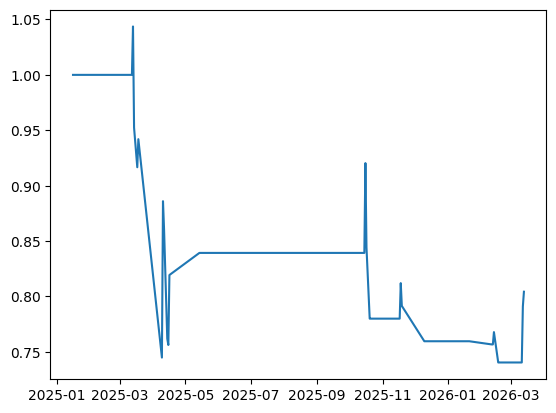

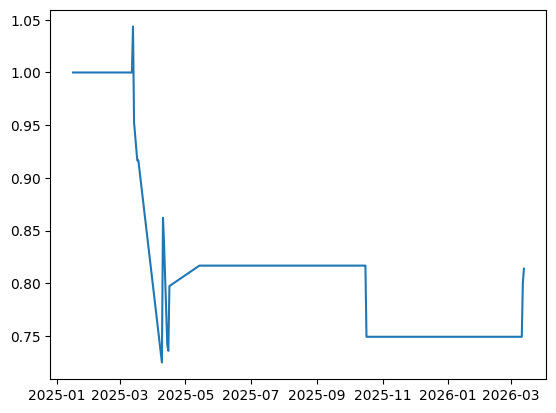

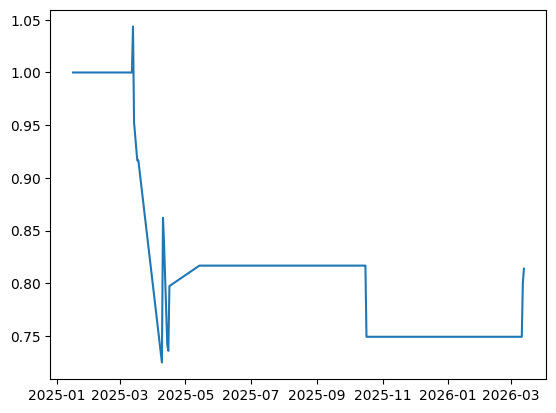

In [15]:
from utils import build_strategy_table, draw_wealth
graph_data = build_strategy_table(data, "7", "30")
seven_thirty = draw_wealth(graph_data, "7/30")
graph_data = build_strategy_table(data, "30", "60")
thirty_sixty = draw_wealth(graph_data, "30/60")
graph_data = build_strategy_table(data, "30", "90")
thirty_ninety = draw_wealth(graph_data, "30/90")